### Data import

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#### Data Structure

The dataset contains the following information:
- Products and Categories: Item name and it's classifications
- Price and Shipping
- Sale date and localization
- Customer feedback
- Payment type and conditions
- Geographic coordinates

#### Data concatenation

In [43]:
loja["Loja"] = "Loja 1"
loja2["Loja"] = "Loja 2"
loja3["Loja"] = "Loja 3"
loja4["Loja"] = "Loja 4"

unified_dataset = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

# 1. Sales Analysis

In [ ]:
print("Total Sales by Store")
store_sales = unified_dataset.groupby("Loja", as_index=False)["Preço"].sum().rename(columns={"Preço": "Valor"})
store_sales

,Loja,Valor
0,Loja 1,1534509.12
1,Loja 2,1488459.06
2,Loja 3,1464025.03
3,Loja 4,1384497.58


Text(0, 0.5, 'Faturamento Total (R$)')

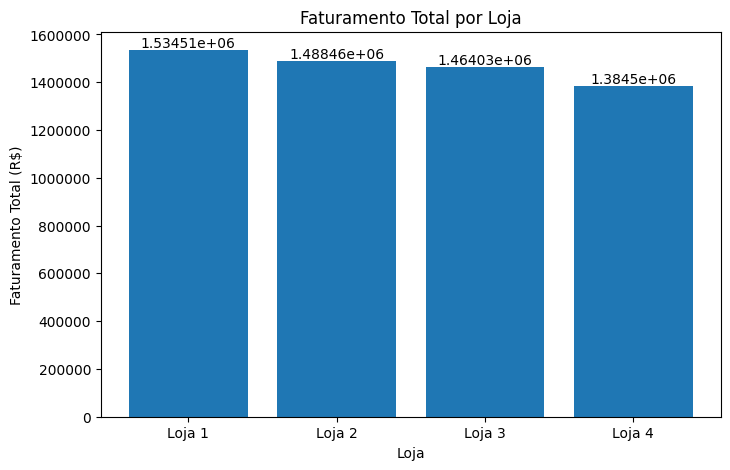

In [53]:
fig1, ax = plt.subplots(figsize=(8,5))
ax.bar(store_sales["Loja"], store_sales["Valor"])

for container in ax.containers:
    ax.bar_label(container)

ax.ticklabel_format(style='plain', axis='y') 
ax.set_title("Faturamento Total por Loja")
ax.set_xlabel("Loja")
ax.set_ylabel("Faturamento Total (R$)")

# 2. Sales by Category

In [ ]:
print("Sales Value by Category")
sales_by_category = unified_dataset.groupby(["Loja", "Categoria do Produto"], as_index=False).size().sort_values(["Loja","size"], ascending=[True, False])
sales_by_category

Sales Value by Category


,Loja,size
0,Loja 1,2359
1,Loja 2,2359
2,Loja 3,2359
3,Loja 4,2358


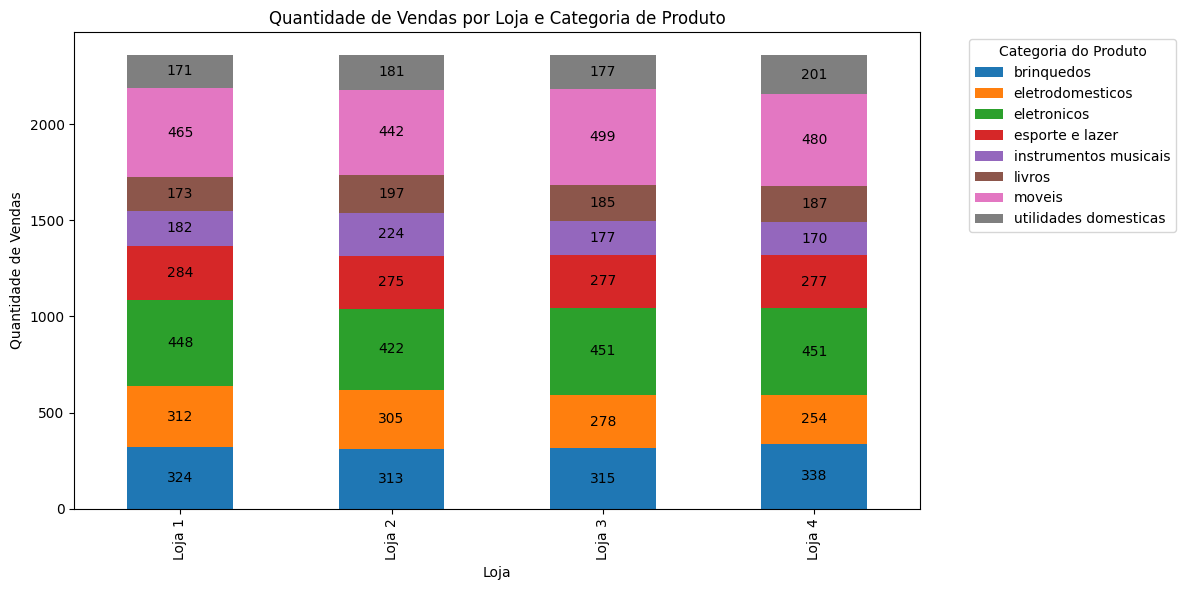

In [47]:
pivot = sales_by_category.pivot(index="Loja", columns="Categoria do Produto", values="size").fillna(0)

ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6))

for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d')
    
plt.title("Quantidade de Vendas por Loja e Categoria de Produto")
plt.xlabel("Loja")
plt.ylabel("Quantidade de Vendas")
plt.legend(title="Categoria do Produto", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

# 3. Feedback averages


In [48]:
print("Average NPS by Store | (x/5)")
unified_dataset.groupby("Loja")["Avaliação da compra"].mean()

Average NPS by Store | (x/5)


Loja
Loja 1    3.976685
Loja 2    4.037304
Loja 3    4.048326
Loja 4    3.995759
Name: Avaliação da compra, dtype: float64

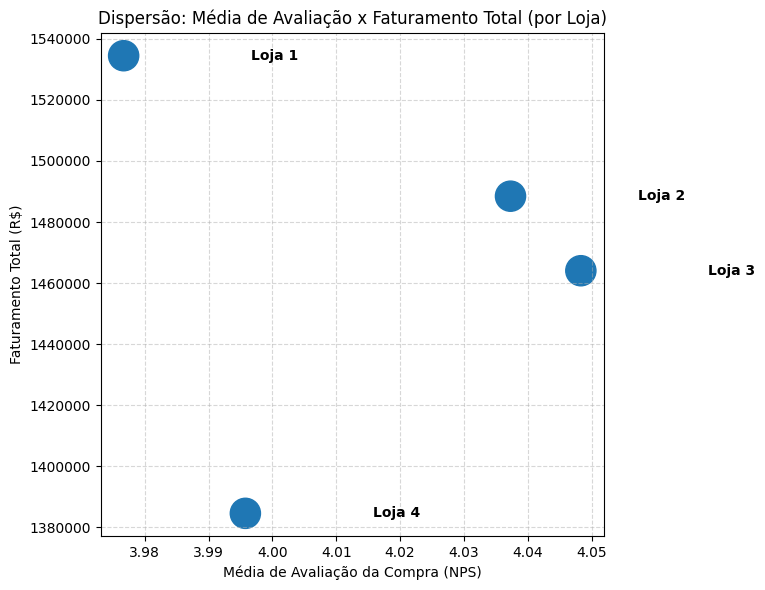

In [82]:
faturamento = unified_dataset.groupby("Loja")["Preço"].sum().rename("Faturamento_Total")
avaliacao = unified_dataset.groupby("Loja")["Avaliação da compra"].mean().rename("Media_Avaliacao")
qtd_vendas = unified_dataset.groupby("Loja")["Preço"].size().rename("Qtd_Vendas")

resumo = pd.concat([faturamento, avaliacao, qtd_vendas], axis=1).reset_index()

plt.figure(figsize=(8, 6))
ax = plt.gca()

plt.scatter(
    resumo["Media_Avaliacao"],
    resumo["Faturamento_Total"],
    s=qtd_vendas/5
)

for i, row in resumo.iterrows():
    ax.text(row["Media_Avaliacao"] + 0.02, row["Faturamento_Total"], row["Loja"],
            fontsize=10, fontweight="bold", va="center")

plt.title("Dispersão: Média de Avaliação x Faturamento Total (por Loja)")
plt.xlabel("Média de Avaliação da Compra (NPS)")
plt.ylabel("Faturamento Total (R$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.ticklabel_format(style="plain", axis="y")  # evitar notação científica
plt.tight_layout()
plt.show()

# 4. Sales best and worst products

In [49]:
base = unified_dataset.groupby(["Loja", "Produto"], as_index=False).size().rename(columns={"size":"Qtd_Vendas"})
blocos = []

for loja, g in base.groupby(["Loja"]):
    g_sorted = g.sort_values("Qtd_Vendas", ascending=False)
    top = g_sorted.head(3).copy(); top["Tipo"] = "Mais Vendidos"
    bottom = g_sorted.sort_values("Qtd_Vendas", ascending=True).head(3).copy(); bottom["Tipo"] = "Menos Vendidos"
    blocos.append(pd.concat([top, bottom], ignore_index=True))

pd.concat(blocos, ignore_index=True)

,Loja,Produto,Qtd_Vendas,Tipo
0,Loja 1,TV Led UHD 4K,60,Mais Vendidos
1,Loja 1,Micro-ondas,60,Mais Vendidos
2,Loja 1,Guarda roupas,60,Mais Vendidos
3,Loja 1,Celular ABXY,33,Menos Vendidos
4,Loja 1,Headset,33,Menos Vendidos
5,Loja 1,Panela de pressão,35,Menos Vendidos
6,Loja 2,Iniciando em programação,65,Mais Vendidos
7,Loja 2,Micro-ondas,62,Mais Vendidos
8,Loja 2,Bateria,61,Mais Vendidos
9,Loja 2,Jogo de tabuleiro,32,Menos Vendidos


# 5. Average shipping by store

In [50]:
print("Average Shipping by Store")
unified_dataset.groupby("Loja")["Frete"].mean()

Average Shipping by Store


Loja
Loja 1    34.691805
Loja 2    33.621941
Loja 3    33.074464
Loja 4    31.278997
Name: Frete, dtype: float64

<Figure size 1200x700 with 0 Axes>

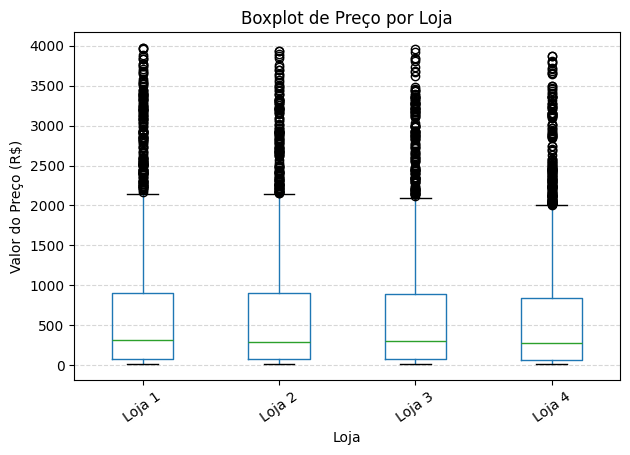

In [83]:
plt.figure(figsize=(12, 7))

unified_dataset.boxplot(column="Preço", by="Loja", grid=False)

plt.title("Boxplot de Preço por Loja")
plt.suptitle("")
plt.xlabel("Loja")
plt.xticks(rotation=35) 
plt.ylabel("Valor do Preço (R$)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Avaliação Final

#### Com base nos dados analisados, tais como faturamento total, número de vendas e avaliação dos clientes, recomenda-se a venda da loja 4.

Em relação ao faturamento, foi a loja que apresentou o pior desempenho.
Em relação a avaliação dos clientes, apresentou o segundo pior desempenho, ficando a frente apenas da loja 1 (que apresentou o maior faturamento).
O fator de frete apresenta forte correlação com o preço da compra, sendo assim, recomenda-se que o mesmo não seja considerado nesta decisão.